# 1 2

In [1]:
from pathlib import Path
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image
import random

DATA_ROOT = Path(r"C:\Users\Hoannd\Downloads\data_face\Image")

TRAIN_DIR = DATA_ROOT / "train_photo"
TEST_DIR = DATA_ROOT / "test_photo"

LIVE_DIR = TRAIN_DIR / "live"
NOT_LIVE_DIR = TRAIN_DIR / "not_live"

OUT_DIR = Path(r"C:\Users\Hoannd\Downloads\data_face\vfa_work")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("Exists DATA_ROOT:", DATA_ROOT.exists())

print("TRAIN_DIR:", TRAIN_DIR, TRAIN_DIR.exists())
print("TEST_DIR:", TEST_DIR, TEST_DIR.exists())
print("LIVE_DIR:", LIVE_DIR, LIVE_DIR.exists())
print("NOT_LIVE_DIR:", NOT_LIVE_DIR, NOT_LIVE_DIR.exists())
print("OUT_DIR:", OUT_DIR)

DATA_ROOT: C:\Users\Hoannd\Downloads\data_face\Image
Exists DATA_ROOT: True
TRAIN_DIR: C:\Users\Hoannd\Downloads\data_face\Image\train_photo True
TEST_DIR: C:\Users\Hoannd\Downloads\data_face\Image\test_photo True
LIVE_DIR: C:\Users\Hoannd\Downloads\data_face\Image\train_photo\live True
NOT_LIVE_DIR: C:\Users\Hoannd\Downloads\data_face\Image\train_photo\not_live True
OUT_DIR: C:\Users\Hoannd\Downloads\data_face\vfa_work


# 3

In [2]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def is_image_file(path: Path):
    return path.is_file() and path.suffix.lower() in IMAGE_EXTS

# 4

In [3]:
records = []

label_map = {
    "live": "real",
    "not_live": "fake"
}

for folder_name, label in label_map.items():
    folder = TRAIN_DIR / folder_name
    
    if not folder.exists():
        print(f"Folder không tồn tại: {folder}")
        continue
    
    for img_path in folder.rglob("*"):
        if is_image_file(img_path):
            records.append({
                "path": str(img_path),
                "relative_path": str(img_path.relative_to(DATA_ROOT)),
                "filename": img_path.name,
                "suffix": img_path.suffix.lower(),
                "source_split": "train_photo",
                "source_folder": folder_name,
                "label": label,
                "size_mb": img_path.stat().st_size / (1024 * 1024)
            })

df_train_raw = pd.DataFrame(records)

print("Tổng số ảnh train_photo:", len(df_train_raw))
display(df_train_raw.head())

Tổng số ảnh train_photo: 9258


,path,relative_path,filename,suffix,source_split,source_folder,label,size_mb
0,C:\Users\Hoannd\Downloads\data_face\Image\trai...,train_photo\live\00054616-b103-11ed-a23e-b42e9...,00054616-b103-11ed-a23e-b42e9920aa06_face_imag...,.jpg,train_photo,live,real,0.241218
1,C:\Users\Hoannd\Downloads\data_face\Image\trai...,train_photo\live\00167348-b13d-11ed-8e2a-b42e9...,00167348-b13d-11ed-8e2a-b42e9920aa06_face_imag...,.jpg,train_photo,live,real,0.339862
2,C:\Users\Hoannd\Downloads\data_face\Image\trai...,train_photo\live\0032863a-b0f4-11ed-95c0-b42e9...,0032863a-b0f4-11ed-95c0-b42e9920aa06_face_imag...,.jpg,train_photo,live,real,0.263576
3,C:\Users\Hoannd\Downloads\data_face\Image\trai...,train_photo\live\0034794a-b07c-11ed-a57b-b42e9...,0034794a-b07c-11ed-a57b-b42e9920aa06_face_imag...,.jpg,train_photo,live,real,0.232270
4,C:\Users\Hoannd\Downloads\data_face\Image\trai...,train_photo\live\00458c9a-b12a-11ed-bdfc-b42e9...,00458c9a-b12a-11ed-bdfc-b42e9920aa06_face_imag...,.jpg,train_photo,live,real,1.418839


# 5

In [4]:
label_count = df_train_raw["label"].value_counts()

display(label_count)

print("Real/live:", label_count.get("real", 0))
print("Fake/not_live:", label_count.get("fake", 0))
print("Tổng:", len(df_train_raw))

label
real    6759
fake    2499
Name: count, dtype: int64

Real/live: 6759
Fake/not_live: 2499
Tổng: 9258


# 6

In [5]:
folder_count = df_train_raw.groupby(["source_folder", "label"]).size().reset_index(name="count")
display(folder_count)

,source_folder,label,count
0,live,real,6759
1,not_live,fake,2499


# 7

In [6]:
total_size_gb = df_train_raw["size_mb"].sum() / 1024

print(f"Tổng dung lượng train_photo quét được: {total_size_gb:.2f} GB")
print(f"Số ảnh: {len(df_train_raw):,}")

Tổng dung lượng train_photo quét được: 5.94 GB
Số ảnh: 9,258


# 8

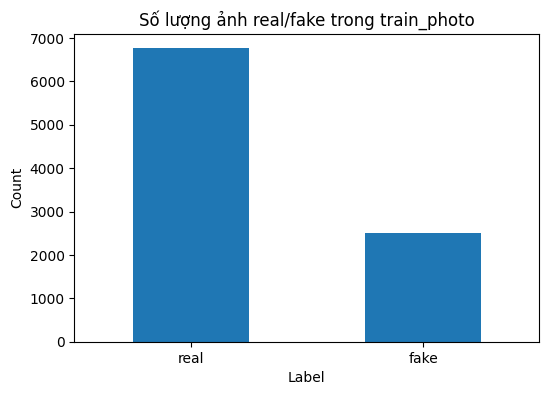

In [7]:
plt.figure(figsize=(6, 4))
df_train_raw["label"].value_counts().plot(kind="bar")
plt.title("Số lượng ảnh real/fake trong train_photo")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# 9

In [8]:
sample_df = df_train_raw.sample(min(1000, len(df_train_raw)), random_state=42)

image_infos = []

for row in sample_df.itertuples():
    img_path = Path(row.path)
    try:
        with Image.open(img_path) as img:
            w, h = img.size
        image_infos.append({
            "path": row.path,
            "label": row.label,
            "width": w,
            "height": h,
            "size_mb": row.size_mb
        })
    except Exception as e:
        image_infos.append({
            "path": row.path,
            "label": row.label,
            "width": None,
            "height": None,
            "size_mb": row.size_mb,
            "error": str(e)
        })

df_image_info = pd.DataFrame(image_infos)

display(df_image_info.head())
display(df_image_info[["width", "height", "size_mb"]].describe())

,path,label,width,height,size_mb
0,C:\Users\Hoannd\Downloads\data_face\Image\trai...,real,580,739,0.123816
1,C:\Users\Hoannd\Downloads\data_face\Image\trai...,fake,3120,4160,4.584241
2,C:\Users\Hoannd\Downloads\data_face\Image\trai...,fake,2448,2448,0.782577
3,C:\Users\Hoannd\Downloads\data_face\Image\trai...,fake,2448,2448,0.878789
4,C:\Users\Hoannd\Downloads\data_face\Image\trai...,fake,4032,3024,2.158385


,width,height,size_mb
count,1000.00000,1000.000000,1000.000000
mean,1145.93300,1319.714000,0.655115
std,893.57846,904.287917,0.861219
min,205.00000,213.000000,0.006560
25%,562.00000,900.000000,0.105348
50%,900.00000,1000.000000,0.335553
75%,1063.50000,1280.000000,0.878313
max,4160.00000,4160.000000,8.335835


# 10

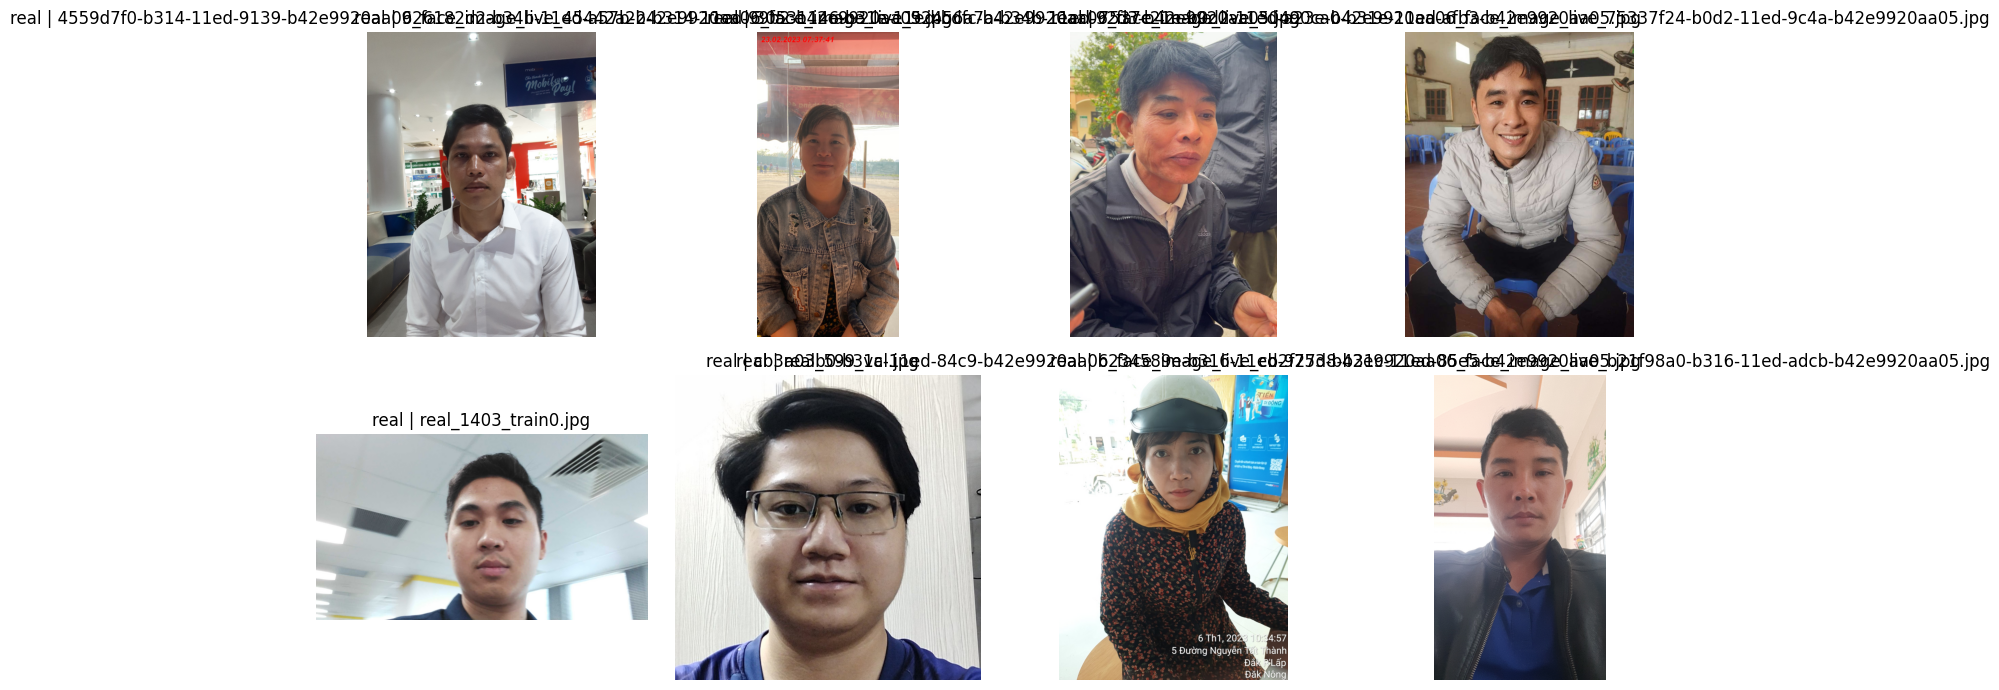

In [9]:
def show_samples(df, label, n=8):
    samples = df[df["label"] == label]
    
    if len(samples) == 0:
        print(f"Không có ảnh label={label}")
        return
    
    samples = samples.sample(min(n, len(samples)), random_state=42)
    
    cols = 4
    rows = 2
    plt.figure(figsize=(14, 7))
    
    for i, row in enumerate(samples.itertuples(), 1):
        img_path = Path(row.path)
        try:
            img = Image.open(img_path).convert("RGB")
            plt.subplot(rows, cols, i)
            plt.imshow(img)
            plt.title(f"{label} | {img_path.name}")
            plt.axis("off")
        except Exception as e:
            print("Lỗi đọc ảnh:", img_path, e)
    
    plt.tight_layout()
    plt.show()

show_samples(df_train_raw, "real", n=8)

# 11

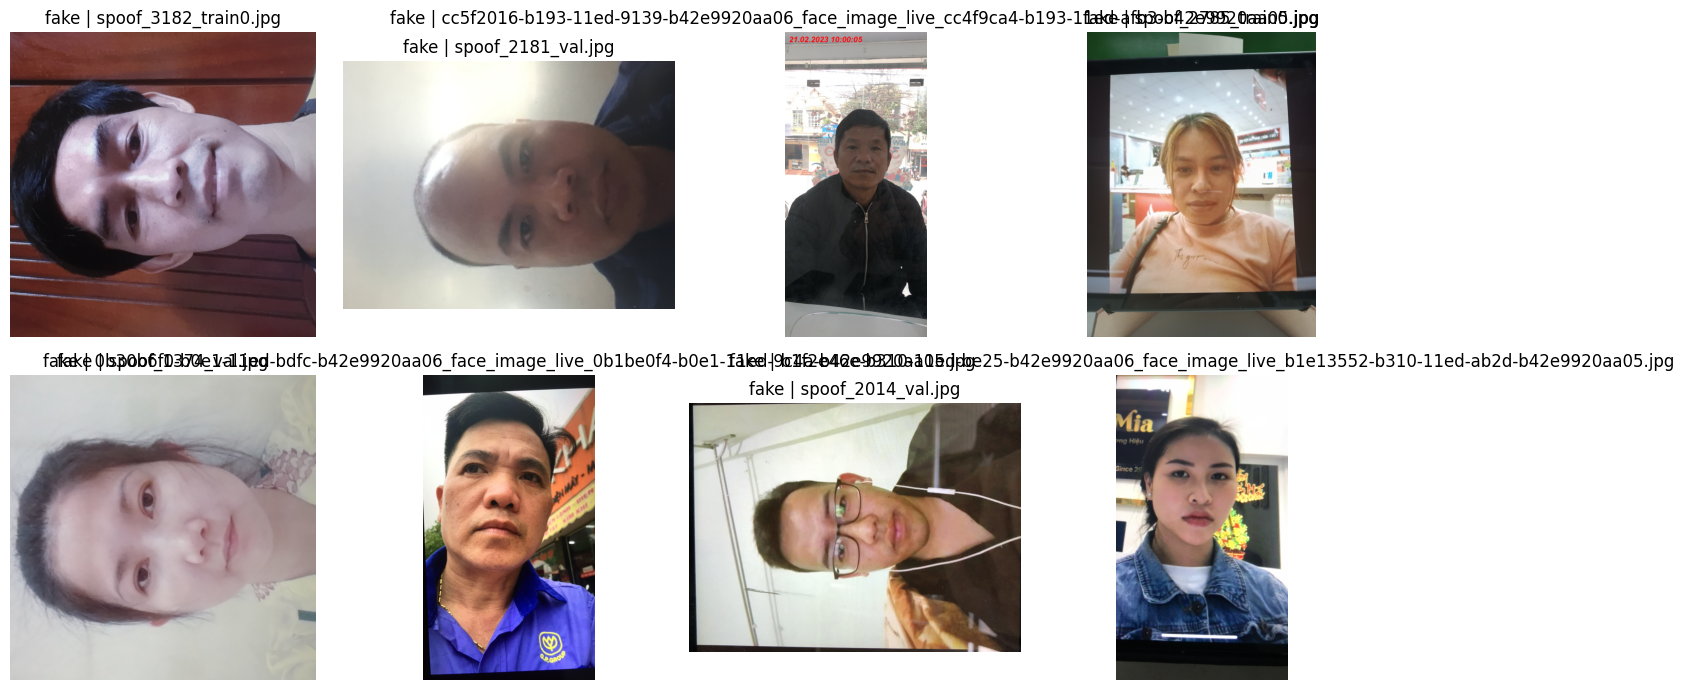

In [10]:
show_samples(df_train_raw, "fake", n=8)

# 12

In [11]:
bad_images = []

for idx, row in enumerate(df_train_raw.itertuples(), 1):
    img_path = Path(row.path)
    
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception as e:
        bad_images.append({
            "path": row.path,
            "relative_path": row.relative_path,
            "label": row.label,
            "error": str(e)
        })
    
    if idx % 5000 == 0:
        print(f"Checked {idx:,}/{len(df_train_raw):,}")

df_bad = pd.DataFrame(bad_images)

print("Số ảnh lỗi:", len(df_bad))
display(df_bad.head(30))

Checked 5,000/9,258
Số ảnh lỗi: 0


""


# 13

In [12]:
if len(df_bad) > 0:
    bad_paths = set(df_bad["path"].tolist())
    df_train_clean = df_train_raw[~df_train_raw["path"].isin(bad_paths)].copy()
else:
    df_train_clean = df_train_raw.copy()

df_train_clean = df_train_clean.reset_index(drop=True)

print("Trước khi lọc:", len(df_train_raw))
print("Sau khi lọc:", len(df_train_clean))

display(df_train_clean["label"].value_counts())

Trước khi lọc: 9258
Sau khi lọc: 9258


label
real    6759
fake    2499
Name: count, dtype: int64

# 14

In [13]:
raw_metadata_path = OUT_DIR / "vfa_train_raw_metadata.csv"
clean_metadata_path = OUT_DIR / "vfa_train_clean_metadata.csv"

df_train_raw.to_csv(raw_metadata_path, index=False, encoding="utf-8-sig")
df_train_clean.to_csv(clean_metadata_path, index=False, encoding="utf-8-sig")

print("Đã lưu raw metadata:")
print(raw_metadata_path)

print("Đã lưu clean metadata:")
print(clean_metadata_path)

Đã lưu raw metadata:
C:\Users\Hoannd\Downloads\data_face\vfa_work\vfa_train_raw_metadata.csv
Đã lưu clean metadata:
C:\Users\Hoannd\Downloads\data_face\vfa_work\vfa_train_clean_metadata.csv


# 15

In [14]:
test_records = []

if TEST_DIR.exists():
    for img_path in TEST_DIR.rglob("*"):
        if is_image_file(img_path):
            test_records.append({
                "path": str(img_path),
                "relative_path": str(img_path.relative_to(DATA_ROOT)),
                "filename": img_path.name,
                "suffix": img_path.suffix.lower(),
                "source_split": "test_photo",
                "parent_folder": img_path.parent.name,
                "size_mb": img_path.stat().st_size / (1024 * 1024)
            })

df_test_raw = pd.DataFrame(test_records)

print("Tổng số ảnh test_photo:", len(df_test_raw))
display(df_test_raw.head())

Tổng số ảnh test_photo: 2118


,path,relative_path,filename,suffix,source_split,parent_folder,size_mb
0,C:\Users\Hoannd\Downloads\data_face\Image\test...,test_photo\live\e004a3f2-b189-11ed-9139-b42e99...,e004a3f2-b189-11ed-9139-b42e9920aa06_face_imag...,.jpg,test_photo,live,0.119617
1,C:\Users\Hoannd\Downloads\data_face\Image\test...,test_photo\live\e00675ea-b31b-11ed-b17c-b42e99...,e00675ea-b31b-11ed-b17c-b42e9920aa06_face_imag...,.jpg,test_photo,live,0.270970
2,C:\Users\Hoannd\Downloads\data_face\Image\test...,test_photo\live\e045326e-b283-11ed-8e2a-b42e99...,e045326e-b283-11ed-8e2a-b42e9920aa06_face_imag...,.jpg,test_photo,live,0.202127
3,C:\Users\Hoannd\Downloads\data_face\Image\test...,test_photo\live\e0667148-b1db-11ed-bdfc-b42e99...,e0667148-b1db-11ed-bdfc-b42e9920aa06_face_imag...,.jpg,test_photo,live,0.160180
4,C:\Users\Hoannd\Downloads\data_face\Image\test...,test_photo\live\e078ee0c-b25a-11ed-bdfc-b42e99...,e078ee0c-b25a-11ed-bdfc-b42e9920aa06_face_imag...,.jpg,test_photo,live,0.162490


# 16

In [15]:
if len(df_test_raw) > 0:
    display(df_test_raw["parent_folder"].value_counts().head(50))
else:
    print("Không tìm thấy ảnh trong test_photo")

parent_folder
not_live    1336
live         782
Name: count, dtype: int64

# 17

In [16]:
test_metadata_path = OUT_DIR / "vfa_test_raw_metadata.csv"

df_test_raw.to_csv(test_metadata_path, index=False, encoding="utf-8-sig")

print("Đã lưu test metadata:")
print(test_metadata_path)

Đã lưu test metadata:
C:\Users\Hoannd\Downloads\data_face\vfa_work\vfa_test_raw_metadata.csv


# 18

In [17]:
def infer_label_from_parent(parent_folder):
    parent_folder = str(parent_folder).lower()
    
    if parent_folder == "live":
        return "real"
    elif parent_folder == "not_live":
        return "fake"
    else:
        return "unknown"

df_test_raw["label"] = df_test_raw["parent_folder"].apply(infer_label_from_parent)

display(df_test_raw["label"].value_counts())
display(df_test_raw.head())

label
fake    1336
real     782
Name: count, dtype: int64

,path,relative_path,filename,suffix,source_split,parent_folder,size_mb,label
0,C:\Users\Hoannd\Downloads\data_face\Image\test...,test_photo\live\e004a3f2-b189-11ed-9139-b42e99...,e004a3f2-b189-11ed-9139-b42e9920aa06_face_imag...,.jpg,test_photo,live,0.119617,real
1,C:\Users\Hoannd\Downloads\data_face\Image\test...,test_photo\live\e00675ea-b31b-11ed-b17c-b42e99...,e00675ea-b31b-11ed-b17c-b42e9920aa06_face_imag...,.jpg,test_photo,live,0.270970,real
2,C:\Users\Hoannd\Downloads\data_face\Image\test...,test_photo\live\e045326e-b283-11ed-8e2a-b42e99...,e045326e-b283-11ed-8e2a-b42e9920aa06_face_imag...,.jpg,test_photo,live,0.202127,real
3,C:\Users\Hoannd\Downloads\data_face\Image\test...,test_photo\live\e0667148-b1db-11ed-bdfc-b42e99...,e0667148-b1db-11ed-bdfc-b42e9920aa06_face_imag...,.jpg,test_photo,live,0.160180,real
4,C:\Users\Hoannd\Downloads\data_face\Image\test...,test_photo\live\e078ee0c-b25a-11ed-bdfc-b42e99...,e078ee0c-b25a-11ed-bdfc-b42e9920aa06_face_imag...,.jpg,test_photo,live,0.162490,real


# 19

In [18]:
df_test_clean = df_test_raw[df_test_raw["label"].isin(["real", "fake"])].copy()
df_test_clean = df_test_clean.reset_index(drop=True)

print("Tổng test clean:", len(df_test_clean))
display(df_test_clean["label"].value_counts())

Tổng test clean: 2118


label
fake    1336
real     782
Name: count, dtype: int64

# 20

In [19]:
from sklearn.model_selection import train_test_split

df_train_split, df_val_split = train_test_split(
    df_train_clean,
    test_size=0.15,
    random_state=42,
    stratify=df_train_clean["label"]
)

df_train_split = df_train_split.copy().reset_index(drop=True)
df_val_split = df_val_split.copy().reset_index(drop=True)

df_train_split["split"] = "train"
df_val_split["split"] = "val"
df_test_clean["split"] = "test"

print("Train:", len(df_train_split))
display(df_train_split["label"].value_counts())

print("Val:", len(df_val_split))
display(df_val_split["label"].value_counts())

print("Test:", len(df_test_clean))
display(df_test_clean["label"].value_counts())

Train: 7869


label
real    5745
fake    2124
Name: count, dtype: int64

Val: 1389


label
real    1014
fake     375
Name: count, dtype: int64

Test: 2118


label
fake    1336
real     782
Name: count, dtype: int64

# 21

In [20]:
common_cols = [
    "path",
    "relative_path",
    "filename",
    "suffix",
    "label",
    "size_mb",
    "split"
]

df_all = pd.concat([
    df_train_split[common_cols],
    df_val_split[common_cols],
    df_test_clean[common_cols]
], ignore_index=True)

print("Tổng toàn bộ dataset:", len(df_all))
display(df_all.groupby(["split", "label"]).size().reset_index(name="count"))
display(df_all.head())

Tổng toàn bộ dataset: 11376


,split,label,count
0,test,fake,1336
1,test,real,782
2,train,fake,2124
3,train,real,5745
4,val,fake,375
5,val,real,1014


,path,relative_path,filename,suffix,label,size_mb,split
0,C:\Users\Hoannd\Downloads\data_face\Image\trai...,train_photo\not_live\spoof_1438_val.jpg,spoof_1438_val.jpg,.jpg,fake,2.000213,train
1,C:\Users\Hoannd\Downloads\data_face\Image\trai...,train_photo\live\real_1552_train0.jpg,real_1552_train0.jpg,.jpg,real,0.080495,train
2,C:\Users\Hoannd\Downloads\data_face\Image\trai...,train_photo\live\467cb066-b306-11ed-b17c-b42e9...,467cb066-b306-11ed-b17c-b42e9920aa06_face_imag...,.jpg,real,0.194368,train
3,C:\Users\Hoannd\Downloads\data_face\Image\trai...,train_photo\live\real_929_train0.jpg,real_929_train0.jpg,.jpg,real,0.012388,train
4,C:\Users\Hoannd\Downloads\data_face\Image\trai...,train_photo\live\dfd9d41a-b319-11ed-9e65-b42e9...,dfd9d41a-b319-11ed-9e65-b42e9920aa06_face_imag...,.jpg,real,0.275164,train


# 22

In [21]:
split_metadata_path = OUT_DIR / "vfa_split_metadata.csv"

df_all.to_csv(split_metadata_path, index=False, encoding="utf-8-sig")

print("Đã lưu metadata split:")
print(split_metadata_path)

Đã lưu metadata split:
C:\Users\Hoannd\Downloads\data_face\vfa_work\vfa_split_metadata.csv


# 23

label,fake,real
split,,
test,1336,782
train,2124,5745
val,375,1014


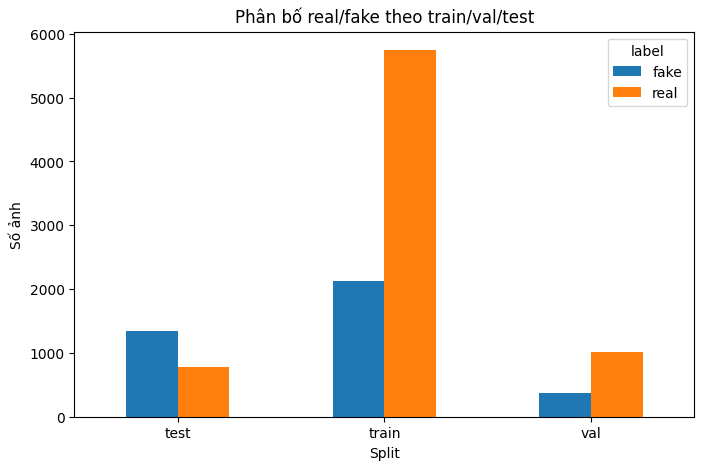

In [22]:
count_df = df_all.groupby(["split", "label"]).size().reset_index(name="count")
pivot_df = count_df.pivot(index="split", columns="label", values="count").fillna(0)

display(pivot_df)

pivot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Phân bố real/fake theo train/val/test")
plt.xlabel("Split")
plt.ylabel("Số ảnh")
plt.xticks(rotation=0)
plt.show()

# 24

In [23]:
PROCESSED_DIR = Path(r"C:\Users\Hoannd\Downloads\data_face\processed_vfa")

for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        folder = PROCESSED_DIR / split / label
        folder.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)
print("Exists:", PROCESSED_DIR.exists())

PROCESSED_DIR: C:\Users\Hoannd\Downloads\data_face\processed_vfa
Exists: True


# 25

In [24]:
import shutil
from tqdm import tqdm

copy_records = []

for row in tqdm(df_all.itertuples(), total=len(df_all)):
    src = Path(row.path)
    
    dst_folder = PROCESSED_DIR / row.split / row.label
    dst_name = f"{row.split}_{row.label}_{row.Index:06d}{src.suffix.lower()}"
    dst = dst_folder / dst_name
    
    if not dst.exists():
        shutil.copy2(src, dst)
    
    copy_records.append({
        "src_path": str(src),
        "dst_path": str(dst),
        "split": row.split,
        "label": row.label
    })

df_copied = pd.DataFrame(copy_records)

display(df_copied.head())
print("Đã copy:", len(df_copied))

100%|██████████| 11376/11376 [00:24<00:00, 462.55it/s]


,src_path,dst_path,split,label
0,C:\Users\Hoannd\Downloads\data_face\Image\trai...,C:\Users\Hoannd\Downloads\data_face\processed_...,train,fake
1,C:\Users\Hoannd\Downloads\data_face\Image\trai...,C:\Users\Hoannd\Downloads\data_face\processed_...,train,real
2,C:\Users\Hoannd\Downloads\data_face\Image\trai...,C:\Users\Hoannd\Downloads\data_face\processed_...,train,real
3,C:\Users\Hoannd\Downloads\data_face\Image\trai...,C:\Users\Hoannd\Downloads\data_face\processed_...,train,real
4,C:\Users\Hoannd\Downloads\data_face\Image\trai...,C:\Users\Hoannd\Downloads\data_face\processed_...,train,real


Đã copy: 11376


# 26

In [25]:
processed_records = []

for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        folder = PROCESSED_DIR / split / label
        files = [p for p in folder.rglob("*") if is_image_file(p)]
        
        processed_records.append({
            "split": split,
            "label": label,
            "count": len(files)
        })

df_processed_check = pd.DataFrame(processed_records)
display(df_processed_check)

,split,label,count
0,train,real,5745
1,train,fake,2124
2,val,real,1014
3,val,fake,375
4,test,real,782
5,test,fake,1336


# 27

In [26]:
processed_metadata_path = OUT_DIR / "vfa_processed_metadata.csv"

df_copied.to_csv(processed_metadata_path, index=False, encoding="utf-8-sig")

print("Đã lưu processed metadata:")
print(processed_metadata_path)

Đã lưu processed metadata:
C:\Users\Hoannd\Downloads\data_face\vfa_work\vfa_processed_metadata.csv


# 28

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# 29

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


# 30

In [29]:
PROCESSED_DIR = Path(r"C:\Users\Hoannd\Downloads\data_face\processed_vfa")

TRAIN_DIR = PROCESSED_DIR / "train"
VAL_DIR = PROCESSED_DIR / "val"
TEST_DIR = PROCESSED_DIR / "test"

print(TRAIN_DIR, TRAIN_DIR.exists())
print(VAL_DIR, VAL_DIR.exists())
print(TEST_DIR, TEST_DIR.exists())

C:\Users\Hoannd\Downloads\data_face\processed_vfa\train True
C:\Users\Hoannd\Downloads\data_face\processed_vfa\val True
C:\Users\Hoannd\Downloads\data_face\processed_vfa\test True


# 31

In [30]:
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.03
    ),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 32

In [31]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds = datasets.ImageFolder(VAL_DIR, transform=eval_tfms)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tfms)

print("Classes:", train_ds.classes)
print("Class to idx:", train_ds.class_to_idx)

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

Classes: ['fake', 'real']
Class to idx: {'fake': 0, 'real': 1}
Train: 7869
Val: 1389
Test: 2118


# 33

In [32]:
BATCH_SIZE = 32
NUM_WORKERS = 0  # Windows notebook nên để 0 cho ít lỗi

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 246
Val batches: 44
Test batches: 67


# 34

In [33]:
from collections import Counter

train_labels = [label for _, label in train_ds.samples]
label_counter = Counter(train_labels)

print("Label counter:", label_counter)
print("Class names:", train_ds.classes)

num_classes = len(train_ds.classes)
total = sum(label_counter.values())

class_weights = []

for class_idx in range(num_classes):
    count = label_counter[class_idx]
    weight = total / (num_classes * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

Label counter: Counter({1: 5745, 0: 2124})
Class names: ['fake', 'real']
Class weights: tensor([1.8524, 0.6849])


# 35

In [34]:
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\Hoannd/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:01<00:00, 5.22MB/s]


Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=2, bias=True)
)


# 36

In [35]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# 37

In [36]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        logits = model(images)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary",
        pos_label=train_ds.class_to_idx["real"],
        zero_division=0
    )
    
    return epoch_loss, epoch_acc, precision, recall, f1

# 38

In [37]:
def evaluate(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images)
            loss = criterion(logits, labels)
            
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            running_loss += loss.item() * images.size(0)
            
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary",
        pos_label=train_ds.class_to_idx["real"],
        zero_division=0
    )
    
    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs)
    }

# 38.1

In [39]:
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

print("Enabled LOAD_TRUNCATED_IMAGES")

Enabled LOAD_TRUNCATED_IMAGES


# 39

In [40]:
EPOCHS = 10

MODEL_DIR = Path(r"C:\Users\Hoannd\Downloads\data_face\models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_val_f1 = 0.0
best_model_path = MODEL_DIR / "vfa_mobilenetv3_small_best.pth"

history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    
    train_loss, train_acc, train_precision, train_recall, train_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )
    
    val_result = evaluate(
        model,
        val_loader,
        criterion,
        device
    )
    
    scheduler.step(val_result["f1"])
    
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "val_loss": val_result["loss"],
        "val_acc": val_result["acc"],
        "val_precision": val_result["precision"],
        "val_recall": val_result["recall"],
        "val_f1": val_result["f1"],
        "lr": optimizer.param_groups[0]["lr"]
    }
    
    history.append(row)
    
    print(
        f"Train loss={train_loss:.4f} acc={train_acc:.4f} f1={train_f1:.4f} | "
        f"Val loss={val_result['loss']:.4f} acc={val_result['acc']:.4f} f1={val_result['f1']:.4f}"
    )
    
    if val_result["f1"] > best_val_f1:
        best_val_f1 = val_result["f1"]
        
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_ds.class_to_idx,
            "classes": train_ds.classes,
            "img_size": IMG_SIZE,
            "epoch": epoch,
            "val_f1": best_val_f1
        }, best_model_path)
        
        print("Saved best model:", best_model_path)

df_history = pd.DataFrame(history)
display(df_history)


Epoch 1/10


Train loss=0.2588 acc=0.9018 f1=0.9310 | Val loss=0.1868 acc=0.9338 f1=0.9532
Saved best model: C:\Users\Hoannd\Downloads\data_face\models\vfa_mobilenetv3_small_best.pth

Epoch 2/10


Train loss=0.1471 acc=0.9419 f1=0.9595 | Val loss=0.1399 acc=0.9546 f1=0.9686
Saved best model: C:\Users\Hoannd\Downloads\data_face\models\vfa_mobilenetv3_small_best.pth

Epoch 3/10


Train loss=0.1153 acc=0.9565 f1=0.9698 | Val loss=0.1356 acc=0.9438 f1=0.9620

Epoch 4/10


Train loss=0.0964 acc=0.9598 f1=0.9721 | Val loss=0.1433 acc=0.9482 f1=0.9641

Epoch 5/10


...

Train loss=0.0508 acc=0.9783 f1=0.9850 | Val loss=0.1745 acc=0.9496 f1=0.9658

Epoch 8/10


Train loss=0.0465 acc=0.9818 f1=0.9875 | Val loss=0.1613 acc=0.9510 f1=0.9668

Epoch 9/10


Train loss=0.0317 acc=0.9878 f1=0.9916 | Val loss=0.1876 acc=0.9525 f1=0.9676

Epoch 10/10


Train loss=0.0288 acc=0.9895 f1=0.9927 | Val loss=0.1670 acc=0.9482 f1=0.9647


,epoch,train_loss,train_acc,train_precision,train_recall,train_f1,val_loss,val_acc,val_precision,val_recall,val_f1,lr
0,1,0.258800,0.901766,0.955478,0.907746,0.931001,0.186843,0.933765,0.985263,0.923077,0.953157,0.00010
1,2,0.147074,0.941924,0.977084,0.942559,0.959511,0.139880,0.954644,0.979818,0.957594,0.968579,0.00010
2,3,0.115285,0.956538,0.984748,0.955265,0.969783,0.135597,0.943844,0.951737,0.972387,0.961951,0.00010
3,4,0.096387,0.959842,0.986906,0.957702,0.972085,0.143333,0.948164,0.973843,0.954635,0.964143,0.00010
4,5,0.079577,0.968738,0.990369,0.966580,0.978330,0.136846,0.954644,0.962099,0.976331,0.969163,0.00010
5,6,0.068204,0.971534,0.990581,0.970235,0.980302,0.148464,0.951044,0.979716,0.952663,0.966000,0.00010
6,7,0.050843,0.978269,0.993624,0.976501,0.984988,0.174516,0.949604,0.956480,0.975345,0.965820,0.00010
7,8,0.046457,0.981827,0.994178,0.980853,0.987470,0.161344,0.951044,0.958333,0.975345,0.966764,0.00005
8,9,0.031748,0.987800,0.996834,0.986423,0.991601,0.187583,0.952484,0.961988,0.973373,0.967647,0.00005
9,10,0.028821,0.989452,0.997540,0.987990,0.992742,0.166997,0.948164,0.959961,0.969428,0.964671,0.00005


# 40

In [41]:
history_path = MODEL_DIR / "vfa_train_history.csv"
df_history.to_csv(history_path, index=False, encoding="utf-8-sig")

print("Saved history:", history_path)

Saved history: C:\Users\Hoannd\Downloads\data_face\models\vfa_train_history.csv


# 41

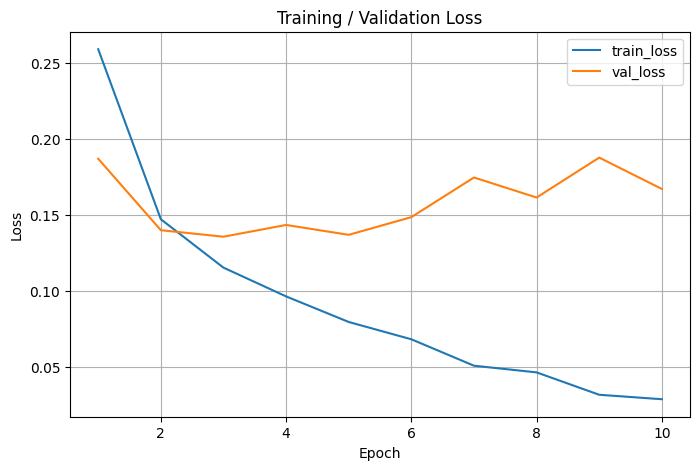

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["train_loss"], label="train_loss")
plt.plot(df_history["epoch"], df_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# 42

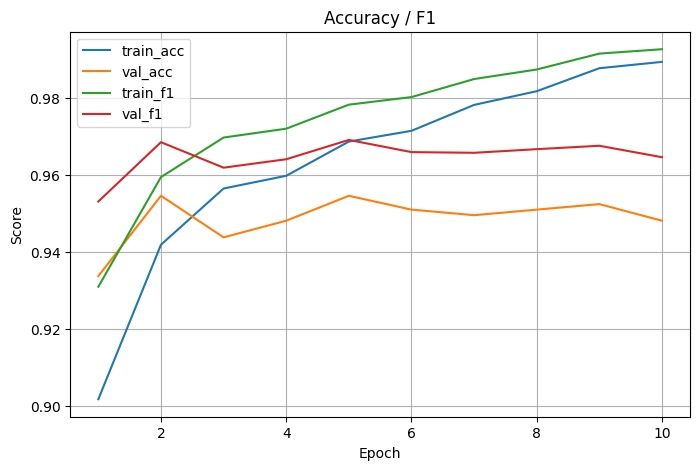

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["train_acc"], label="train_acc")
plt.plot(df_history["epoch"], df_history["val_acc"], label="val_acc")
plt.plot(df_history["epoch"], df_history["train_f1"], label="train_f1")
plt.plot(df_history["epoch"], df_history["val_f1"], label="val_f1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Accuracy / F1")
plt.legend()
plt.grid(True)
plt.show()

# 43

In [44]:
checkpoint = torch.load(best_model_path, map_location=device)

best_model = models.mobilenet_v3_small(weights=None)
in_features = best_model.classifier[3].in_features
best_model.classifier[3] = nn.Linear(in_features, num_classes)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model = best_model.to(device)
best_model.eval()

print("Loaded:", best_model_path)
print("Classes:", checkpoint["classes"])
print("Best epoch:", checkpoint["epoch"])
print("Best val_f1:", checkpoint["val_f1"])

Loaded: C:\Users\Hoannd\Downloads\data_face\models\vfa_mobilenetv3_small_best.pth
Classes: ['fake', 'real']
Best epoch: 5
Best val_f1: 0.9691629955947136


# 44

In [45]:
test_result = evaluate(
    best_model,
    test_loader,
    criterion,
    device
)

print("Test loss:", test_result["loss"])
print("Test acc:", test_result["acc"])
print("Test precision:", test_result["precision"])
print("Test recall:", test_result["recall"])
print("Test f1:", test_result["f1"])

Test loss: 0.17113772138817007
Test acc: 0.940982058545798
Test precision: 0.8860164512338425
Test recall: 0.9641943734015346
Test f1: 0.9234537660747091


# 45

In [46]:
y_true = test_result["labels"]
y_pred = test_result["preds"]

print("Class mapping:", train_ds.class_to_idx)

print(classification_report(
    y_true,
    y_pred,
    target_names=train_ds.classes,
    digits=4
))

Class mapping: {'fake': 0, 'real': 1}
              precision    recall  f1-score   support

        fake     0.9779    0.9274    0.9520      1336
        real     0.8860    0.9642    0.9235       782

    accuracy                         0.9410      2118
   macro avg     0.9320    0.9458    0.9377      2118
weighted avg     0.9440    0.9410    0.9414      2118



# 46

,pred_fake,pred_real
true_fake,1239,97
true_real,28,754


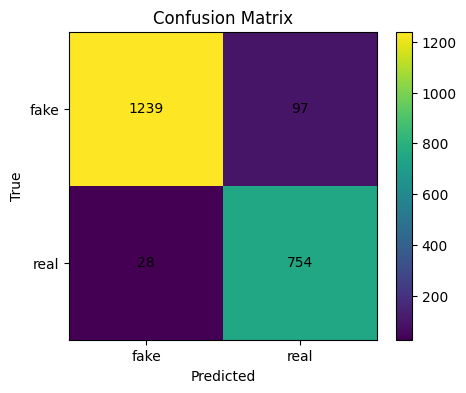

In [47]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in train_ds.classes],
    columns=[f"pred_{c}" for c in train_ds.classes]
)

display(cm_df)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(train_ds.classes)), train_ds.classes)
plt.yticks(range(len(train_ds.classes)), train_ds.classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

# 47

In [48]:
from PIL import Image

idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

def predict_image(image_path, model, transform, device, threshold_real=0.5):
    image_path = Path(image_path)
    img = Image.open(image_path).convert("RGB")
    
    x = transform(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
    
    fake_idx = train_ds.class_to_idx["fake"]
    real_idx = train_ds.class_to_idx["real"]
    
    fake_score = float(probs[fake_idx])
    real_score = float(probs[real_idx])
    
    if real_score >= threshold_real:
        pred_label = "real"
    else:
        pred_label = "fake"
    
    return {
        "image_path": str(image_path),
        "pred_label": pred_label,
        "real_score": real_score,
        "fake_score": fake_score
    }

# 48

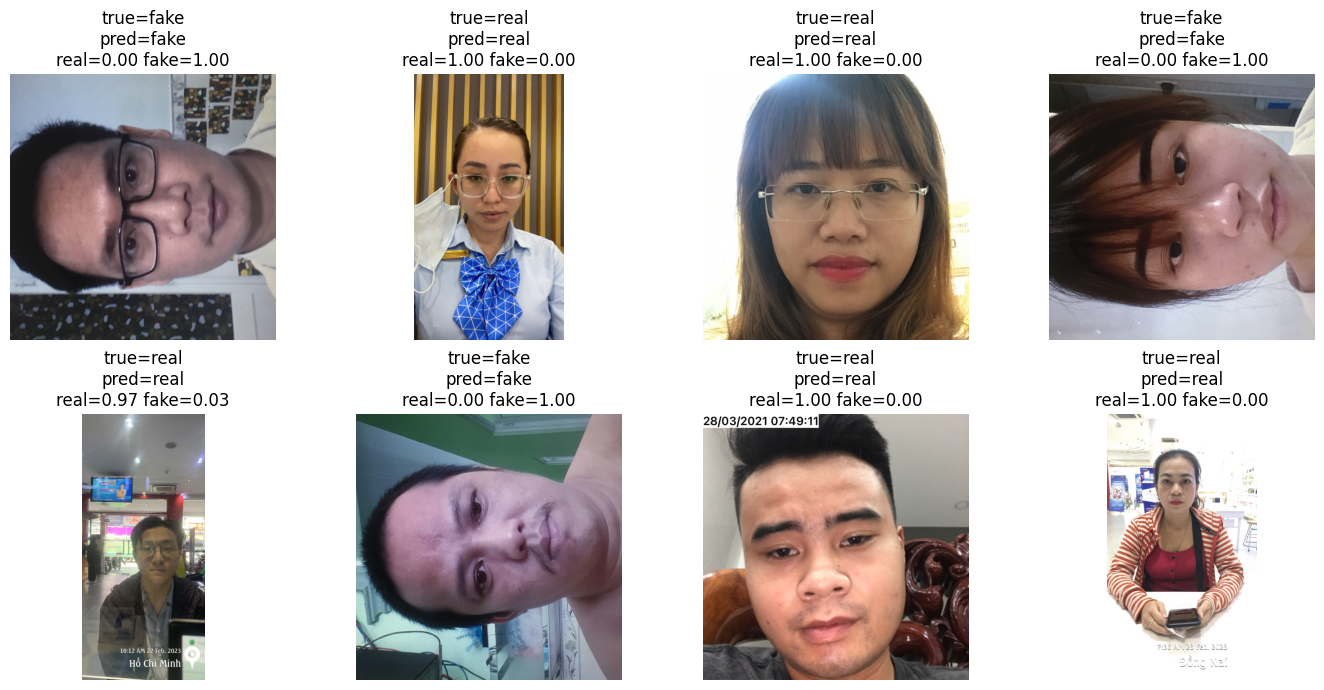

In [49]:
sample_paths = random.sample(test_ds.samples, k=min(8, len(test_ds.samples)))

plt.figure(figsize=(14, 7))

for i, (img_path, true_idx) in enumerate(sample_paths, 1):
    result = predict_image(img_path, best_model, eval_tfms, device)
    
    img = Image.open(img_path).convert("RGB")
    
    true_label = idx_to_class[true_idx]
    pred_label = result["pred_label"]
    real_score = result["real_score"]
    fake_score = result["fake_score"]
    
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(
        f"true={true_label}\npred={pred_label}\nreal={real_score:.2f} fake={fake_score:.2f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# 49

In [50]:
test_samples = test_ds.samples
wrong_records = []

for i, (img_path, true_idx) in enumerate(test_samples):
    pred_idx = y_pred[i]
    
    if pred_idx != true_idx:
        probs = test_result["probs"][i]
        wrong_records.append({
            "path": img_path,
            "true_label": idx_to_class[true_idx],
            "pred_label": idx_to_class[pred_idx],
            "fake_score": float(probs[train_ds.class_to_idx["fake"]]),
            "real_score": float(probs[train_ds.class_to_idx["real"]])
        })

df_wrong = pd.DataFrame(wrong_records)

print("Số ảnh test sai:", len(df_wrong))
display(df_wrong.head(30))

Số ảnh test sai: 125


,path,true_label,pred_label,fake_score,real_score
0,C:\Users\Hoannd\Downloads\data_face\processed_...,fake,real,0.377611,0.622389
1,C:\Users\Hoannd\Downloads\data_face\processed_...,fake,real,0.150666,0.849334
2,C:\Users\Hoannd\Downloads\data_face\processed_...,fake,real,0.033851,0.966149
3,C:\Users\Hoannd\Downloads\data_face\processed_...,fake,real,0.271065,0.728935
4,C:\Users\Hoannd\Downloads\data_face\processed_...,fake,real,0.403704,0.596296
5,C:\Users\Hoannd\Downloads\data_face\processed_...,fake,real,0.419716,0.580284
6,C:\Users\Hoannd\Downloads\data_face\processed_...,fake,real,0.033089,0.966911
7,C:\Users\Hoannd\Downloads\data_face\processed_...,fake,real,0.100084,0.899916
8,C:\Users\Hoannd\Downloads\data_face\processed_...,fake,real,0.031359,0.968641
9,C:\Users\Hoannd\Downloads\data_face\processed_...,fake,real,0.203869,0.796131


# 50

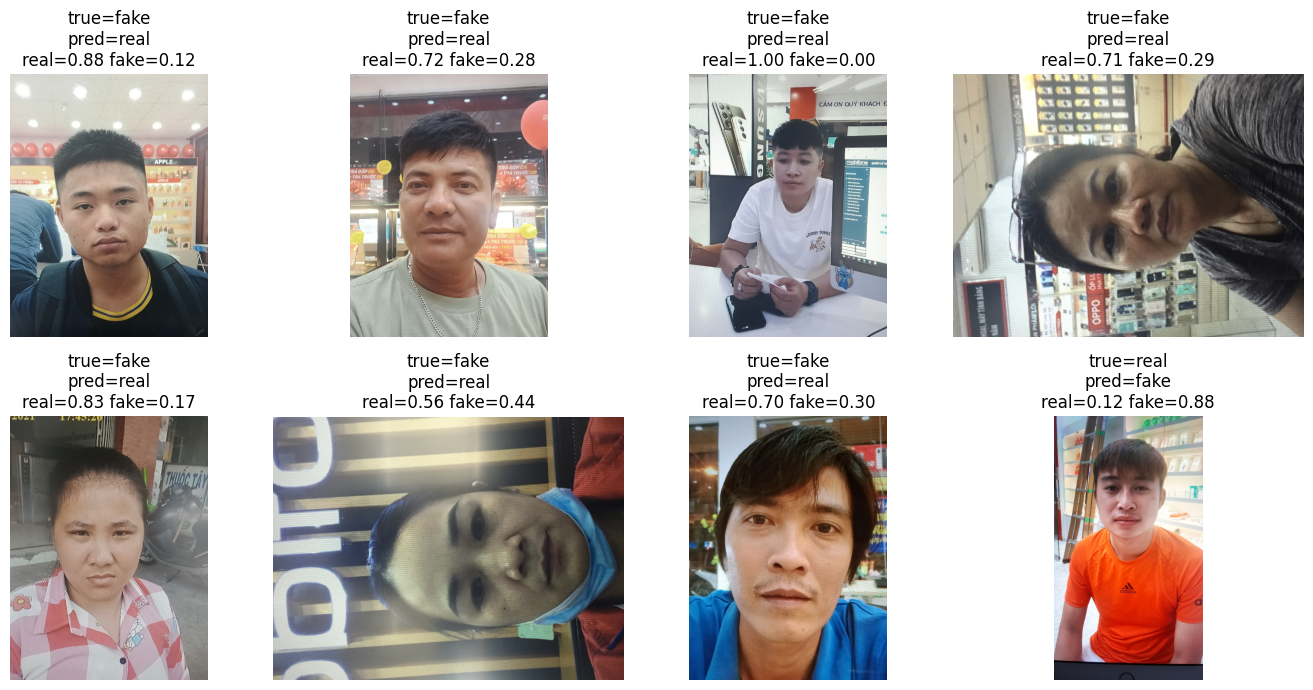

In [51]:
def show_wrong_samples(df_wrong, n=8):
    if len(df_wrong) == 0:
        print("Không có ảnh sai.")
        return
    
    samples = df_wrong.sample(min(n, len(df_wrong)), random_state=42)
    
    plt.figure(figsize=(14, 7))
    
    for i, row in enumerate(samples.itertuples(), 1):
        img = Image.open(row.path).convert("RGB")
        
        plt.subplot(2, 4, i)
        plt.imshow(img)
        plt.title(
            f"true={row.true_label}\npred={row.pred_label}\nreal={row.real_score:.2f} fake={row.fake_score:.2f}"
        )
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_wrong_samples(df_wrong, n=8)

# 51

In [52]:
fake_idx = train_ds.class_to_idx["fake"]
real_idx = train_ds.class_to_idx["real"]

df_test_score = pd.DataFrame({
    "true_idx": y_true,
    "pred_idx_argmax": y_pred,
    "fake_score": test_result["probs"][:, fake_idx],
    "real_score": test_result["probs"][:, real_idx],
})

idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

df_test_score["true_label"] = df_test_score["true_idx"].map(idx_to_class)
df_test_score["pred_label_argmax"] = df_test_score["pred_idx_argmax"].map(idx_to_class)

display(df_test_score.head())
display(df_test_score.groupby("true_label")[["real_score", "fake_score"]].describe())

,true_idx,pred_idx_argmax,fake_score,real_score,true_label,pred_label_argmax
0,0,1,0.377611,0.622389,fake,real
1,0,0,0.999907,0.000093,fake,fake
2,0,0,0.769713,0.230287,fake,fake
3,0,0,0.984613,0.015387,fake,fake
4,0,0,0.850097,0.149903,fake,fake


real_score                                                        \
                count      mean       std           min       25%       50%   
true_label                                                                    
fake           1336.0  0.083827  0.221379  8.982742e-07  0.000192  0.001657   
real            782.0  0.955964  0.152646  7.810902e-03  0.996637  0.999848   

                               fake_score                                    \
                 75%       max      count      mean       std           min   
true_label                                                                    
fake        0.020130  0.999993     1336.0  0.916173  0.221379  7.127183e-06   
real        0.999985  1.000000      782.0  0.044036  0.152646  1.640027e-08   

                                                    
                 25%       50%       75%       max  
true_label                                          
fake        0.979870  0.998343  0.999808  0.999999  
real        0.000015  0.000152  0.003363  0.992189

# 52

In [53]:
thresholds = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

rows = []

for th in thresholds:
    pred_label = np.where(df_test_score["real_score"] >= th, "real", "fake")
    true_label = df_test_score["true_label"].values
    
    total = len(true_label)
    
    fake_total = np.sum(true_label == "fake")
    real_total = np.sum(true_label == "real")
    
    fake_as_real = np.sum((true_label == "fake") & (pred_label == "real"))
    fake_as_fake = np.sum((true_label == "fake") & (pred_label == "fake"))
    
    real_as_fake = np.sum((true_label == "real") & (pred_label == "fake"))
    real_as_real = np.sum((true_label == "real") & (pred_label == "real"))
    
    acc = np.mean(pred_label == true_label)
    
    apcer = fake_as_real / fake_total
    bpcer = real_as_fake / real_total
    
    rows.append({
        "threshold_real": th,
        "accuracy": acc,
        "fake_total": fake_total,
        "fake_correct": fake_as_fake,
        "fake_as_real_BAD": fake_as_real,
        "APCER_fake_accept_rate": apcer,
        "real_total": real_total,
        "real_correct": real_as_real,
        "real_as_fake": real_as_fake,
        "BPCER_real_reject_rate": bpcer,
    })

df_threshold = pd.DataFrame(rows)

display(df_threshold)

,threshold_real,accuracy,fake_total,fake_correct,fake_as_real_BAD,APCER_fake_accept_rate,real_total,real_correct,real_as_fake,BPCER_real_reject_rate
0,0.50,0.940982,1336,1239,97,0.072605,782,754,28,0.035806
1,0.60,0.943815,1336,1252,84,0.062874,782,747,35,0.044757
2,0.70,0.948064,1336,1264,72,0.053892,782,744,38,0.048593
3,0.75,0.948536,1336,1271,65,0.048653,782,738,44,0.056266
4,0.80,0.950425,1336,1281,55,0.041168,782,732,50,0.063939
5,0.85,0.951369,1336,1287,49,0.036677,782,728,54,0.069054
6,0.90,0.948064,1336,1295,41,0.030689,782,713,69,0.088235
7,0.95,0.941926,1336,1302,34,0.025449,782,693,89,0.113811


# 53

In [54]:
target_apcer = 0.03

candidate_df = df_threshold[df_threshold["APCER_fake_accept_rate"] <= target_apcer].copy()

if len(candidate_df) > 0:
    best_row = candidate_df.sort_values("accuracy", ascending=False).iloc[0]
    display(best_row)
else:
    print("Chưa có threshold nào đạt APCER <=", target_apcer)
    display(df_threshold.sort_values("APCER_fake_accept_rate"))

threshold_real               0.950000
accuracy                     0.941926
fake_total                1336.000000
fake_correct              1302.000000
fake_as_real_BAD            34.000000
APCER_fake_accept_rate       0.025449
real_total                 782.000000
real_correct               693.000000
real_as_fake                89.000000
BPCER_real_reject_rate       0.113811
Name: 7, dtype: float64

# 54

In [55]:
fine_thresholds = np.arange(0.5, 0.991, 0.01)

rows = []

for th in fine_thresholds:
    pred_label = np.where(df_test_score["real_score"] >= th, "real", "fake")
    true_label = df_test_score["true_label"].values
    
    fake_total = np.sum(true_label == "fake")
    real_total = np.sum(true_label == "real")
    
    fake_as_real = np.sum((true_label == "fake") & (pred_label == "real"))
    real_as_fake = np.sum((true_label == "real") & (pred_label == "fake"))
    
    acc = np.mean(pred_label == true_label)
    apcer = fake_as_real / fake_total
    bpcer = real_as_fake / real_total
    
    rows.append({
        "threshold_real": round(float(th), 2),
        "accuracy": acc,
        "APCER_fake_accept_rate": apcer,
        "BPCER_real_reject_rate": bpcer,
        "fake_as_real_BAD": fake_as_real,
        "real_as_fake": real_as_fake,
    })

df_threshold_fine = pd.DataFrame(rows)

display(df_threshold_fine.head())
display(df_threshold_fine.sort_values("APCER_fake_accept_rate").head(20))

,threshold_real,accuracy,APCER_fake_accept_rate,BPCER_real_reject_rate,fake_as_real_BAD,real_as_fake
0,0.50,0.940982,0.072605,0.035806,97,28
1,0.51,0.940982,0.071856,0.037084,96,29
2,0.52,0.940982,0.071856,0.037084,96,29
3,0.53,0.942871,0.068862,0.037084,92,29
4,0.54,0.942871,0.068114,0.038363,91,30


,threshold_real,accuracy,APCER_fake_accept_rate,BPCER_real_reject_rate,fake_as_real_BAD,real_as_fake
49,0.99,0.922568,0.010479,0.191816,14,150
48,0.98,0.932011,0.016467,0.156010,22,122
47,0.97,0.935316,0.018713,0.143223,25,112
46,0.96,0.937677,0.023952,0.127877,32,100
45,0.95,0.941926,0.025449,0.113811,34,89
43,0.93,0.946648,0.026946,0.098465,36,77
44,0.94,0.943343,0.026946,0.107417,36,84
42,0.92,0.946648,0.027695,0.097187,37,76
40,0.90,0.948064,0.030689,0.088235,41,69
41,0.91,0.946648,0.030689,0.092072,41,72


# 55

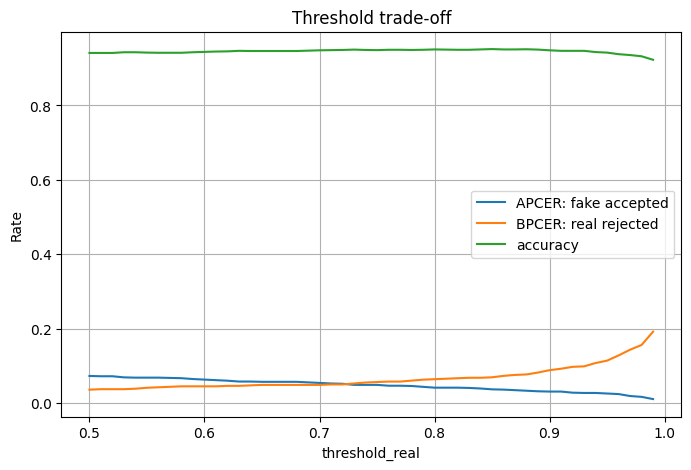

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(df_threshold_fine["threshold_real"], df_threshold_fine["APCER_fake_accept_rate"], label="APCER: fake accepted")
plt.plot(df_threshold_fine["threshold_real"], df_threshold_fine["BPCER_real_reject_rate"], label="BPCER: real rejected")
plt.plot(df_threshold_fine["threshold_real"], df_threshold_fine["accuracy"], label="accuracy")

plt.xlabel("threshold_real")
plt.ylabel("Rate")
plt.title("Threshold trade-off")
plt.legend()
plt.grid(True)
plt.show()

# 56

In [57]:
DEPLOY_THRESHOLD_REAL = 0.75

pred_label_threshold = np.where(
    df_test_score["real_score"] >= DEPLOY_THRESHOLD_REAL,
    "real",
    "fake"
)

true_label = df_test_score["true_label"].values

print("Threshold:", DEPLOY_THRESHOLD_REAL)
print(classification_report(
    true_label,
    pred_label_threshold,
    target_names=["fake", "real"],
    digits=4
))

cm_th = confusion_matrix(true_label, pred_label_threshold, labels=["fake", "real"])

cm_th_df = pd.DataFrame(
    cm_th,
    index=["true_fake", "true_real"],
    columns=["pred_fake", "pred_real"]
)

display(cm_th_df)

Threshold: 0.75
              precision    recall  f1-score   support

        fake     0.9665    0.9513    0.9589      1336
        real     0.9191    0.9437    0.9312       782

    accuracy                         0.9485      2118
   macro avg     0.9428    0.9475    0.9451      2118
weighted avg     0.9490    0.9485    0.9487      2118



,pred_fake,pred_real
true_fake,1271,65
true_real,44,738


# 57

In [58]:
DEPLOY_THRESHOLD_REAL = 0.90

print("Deploy threshold real:", DEPLOY_THRESHOLD_REAL)

Deploy threshold real: 0.9


# 58

In [59]:
pred_label_threshold = np.where(
    df_test_score["real_score"] >= DEPLOY_THRESHOLD_REAL,
    "real",
    "fake"
)

true_label = df_test_score["true_label"].values

print("Threshold:", DEPLOY_THRESHOLD_REAL)

print(classification_report(
    true_label,
    pred_label_threshold,
    labels=["fake", "real"],
    target_names=["fake", "real"],
    digits=4
))

cm_th = confusion_matrix(
    true_label,
    pred_label_threshold,
    labels=["fake", "real"]
)

cm_th_df = pd.DataFrame(
    cm_th,
    index=["true_fake", "true_real"],
    columns=["pred_fake", "pred_real"]
)

display(cm_th_df)

Threshold: 0.9
              precision    recall  f1-score   support

        fake     0.9494    0.9693    0.9593      1336
        real     0.9456    0.9118    0.9284       782

    accuracy                         0.9481      2118
   macro avg     0.9475    0.9405    0.9438      2118
weighted avg     0.9480    0.9481    0.9479      2118



,pred_fake,pred_real
true_fake,1295,41
true_real,69,713


# 59

In [60]:
import json

deploy_config = {
    "model_name": "vfa_mobilenetv3_small",
    "model_path": str(best_model_path),
    "img_size": IMG_SIZE,
    "class_to_idx": train_ds.class_to_idx,
    "idx_to_class": idx_to_class,
    "deploy_threshold_real": DEPLOY_THRESHOLD_REAL,
    "test_accuracy_argmax": float(test_result["acc"]),
    "note": "Predict real only if real_score >= deploy_threshold_real, otherwise fake."
}

config_path = MODEL_DIR / "vfa_deploy_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(deploy_config, f, ensure_ascii=False, indent=2)

print("Saved config:", config_path)
deploy_config

Saved config: C:\Users\Hoannd\Downloads\data_face\models\vfa_deploy_config.json


{'model_name': 'vfa_mobilenetv3_small',
 'model_path': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models\\vfa_mobilenetv3_small_best.pth',
 'img_size': 224,
 'class_to_idx': {'fake': 0, 'real': 1},
 'idx_to_class': {0: 'fake', 1: 'real'},
 'deploy_threshold_real': 0.9,
 'test_accuracy_argmax': 0.940982058545798,
 'note': 'Predict real only if real_score >= deploy_threshold_real, otherwise fake.'}

# 60

In [62]:
IMAGE_PATH = r"C:\Users\Hoannd\Downloads\data_face\processed_vfa\test\fake\test_fake_011350.jpg"

result = predict_image(
    IMAGE_PATH,
    best_model,
    eval_tfms,
    device,
    threshold_real=DEPLOY_THRESHOLD_REAL
)

result

{'image_path': 'C:\\Users\\Hoannd\\Downloads\\data_face\\processed_vfa\\test\\fake\\test_fake_011350.jpg',
 'pred_label': 'fake',
 'real_score': 0.00036688250838778913,
 'fake_score': 0.9996330738067627}

# 61

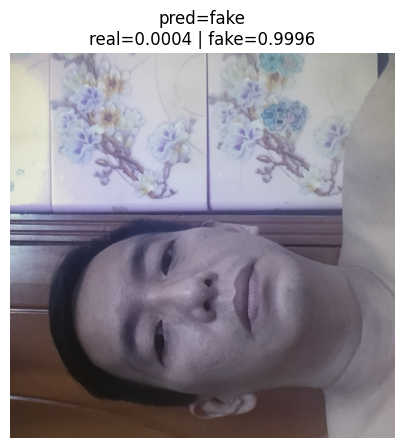

In [63]:
img = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"pred={result['pred_label']}\n"
    f"real={result['real_score']:.4f} | fake={result['fake_score']:.4f}"
)
plt.show()

# 62 63

In [64]:
import cv2
import mediapipe as mp
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import shutil

# 64

In [65]:
FACE_CROP_DIR = Path(r"C:\Users\Hoannd\Downloads\data_face\processed_vfa_face_crop")

for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        (FACE_CROP_DIR / split / label).mkdir(parents=True, exist_ok=True)

print("FACE_CROP_DIR:", FACE_CROP_DIR)

FACE_CROP_DIR: C:\Users\Hoannd\Downloads\data_face\processed_vfa_face_crop


# 64.1

In [67]:
import mediapipe as mp

print("mediapipe module:", mp)
print("mediapipe file:", getattr(mp, "__file__", None))
print("mediapipe version:", getattr(mp, "__version__", None))
print("has solutions:", hasattr(mp, "solutions"))

mediapipe module: <module 'mediapipe' from 'c:\\Users\\Hoannd\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\mediapipe\\__init__.py'>
mediapipe file: c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\mediapipe\__init__.py
mediapipe version: 0.10.35
has solutions: False


# 65

In [68]:
import cv2
from PIL import Image
from pathlib import Path
import numpy as np

haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_path)

print("Haar cascade loaded:", not face_cascade.empty())
print("Haar path:", haar_path)


def center_crop_fallback(img_rgb, output_path, size=224):
    """
    Fallback nếu không detect được mặt:
    crop vùng giữa ảnh rồi resize 224x224.
    """
    h, w = img_rgb.shape[:2]
    
    side = min(h, w)
    x1 = (w - side) // 2
    y1 = (h - side) // 2
    x2 = x1 + side
    y2 = y1 + side
    
    crop = img_rgb[y1:y2, x1:x2]
    crop_pil = Image.fromarray(crop).convert("RGB")
    crop_pil = crop_pil.resize((size, size))
    
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    crop_pil.save(output_path, quality=95)
    
    return True, "center_crop_fallback"


def crop_face_opencv(
    image_path,
    output_path,
    margin=0.35,
    size=224,
    use_fallback=True
):
    image_path = Path(image_path)
    output_path = Path(output_path)
    
    img_bgr = cv2.imread(str(image_path))
    
    if img_bgr is None:
        return False, "cv2_read_failed"
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    h, w = img_rgb.shape[:2]
    
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(40, 40)
    )
    
    if len(faces) == 0:
        if use_fallback:
            return center_crop_fallback(img_rgb, output_path, size=size)
        return False, "no_face"
    
    # Chọn mặt lớn nhất
    faces = sorted(faces, key=lambda box: box[2] * box[3], reverse=True)
    x, y, fw, fh = faces[0]
    
    x1 = x
    y1 = y
    x2 = x + fw
    y2 = y + fh
    
    mx = int(fw * margin)
    my = int(fh * margin)
    
    x1 = max(0, x1 - mx)
    y1 = max(0, y1 - my)
    x2 = min(w, x2 + mx)
    y2 = min(h, y2 + my)
    
    if x2 <= x1 or y2 <= y1:
        if use_fallback:
            return center_crop_fallback(img_rgb, output_path, size=size)
        return False, "invalid_bbox"
    
    crop = img_rgb[y1:y2, x1:x2]
    
    crop_pil = Image.fromarray(crop).convert("RGB")
    crop_pil = crop_pil.resize((size, size))
    
    output_path.parent.mkdir(parents=True, exist_ok=True)
    crop_pil.save(output_path, quality=95)
    
    return True, "ok"

Haar cascade loaded: True
Haar path: c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml


# 66

In [69]:
from tqdm import tqdm
import pandas as pd

crop_records = []

all_items = []

for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        src_folder = PROCESSED_DIR / split / label
        
        for p in src_folder.rglob("*"):
            if p.suffix.lower() in IMAGE_EXTS:
                all_items.append((p, split, label))

print("Tổng ảnh cần crop:", len(all_items))

for idx, (src, split, label) in enumerate(tqdm(all_items), 1):
    dst = FACE_CROP_DIR / split / label / f"{split}_{label}_{idx:06d}.jpg"
    
    if dst.exists():
        ok, reason = True, "exists"
    else:
        ok, reason = crop_face_opencv(
            src,
            dst,
            margin=0.35,
            size=224,
            use_fallback=True
        )
    
    crop_records.append({
        "src_path": str(src),
        "dst_path": str(dst),
        "split": split,
        "label": label,
        "ok": ok,
        "reason": reason
    })

df_crop = pd.DataFrame(crop_records)

display(df_crop["reason"].value_counts())
display(df_crop.groupby(["split", "label", "ok"]).size().reset_index(name="count"))

Tổng ảnh cần crop: 11376


100%|██████████| 11376/11376 [17:33<00:00, 10.80it/s]


reason
ok                      11034
center_crop_fallback      342
Name: count, dtype: int64

,split,label,ok,count
0,test,fake,True,1336
1,test,real,True,782
2,train,fake,True,2124
3,train,real,True,5745
4,val,fake,True,375
5,val,real,True,1014


# 67

In [70]:
crop_metadata_path = OUT_DIR / "vfa_face_crop_metadata.csv"

df_crop.to_csv(crop_metadata_path, index=False, encoding="utf-8-sig")

print("Saved:", crop_metadata_path)

Saved: C:\Users\Hoannd\Downloads\data_face\vfa_work\vfa_face_crop_metadata.csv


# 68

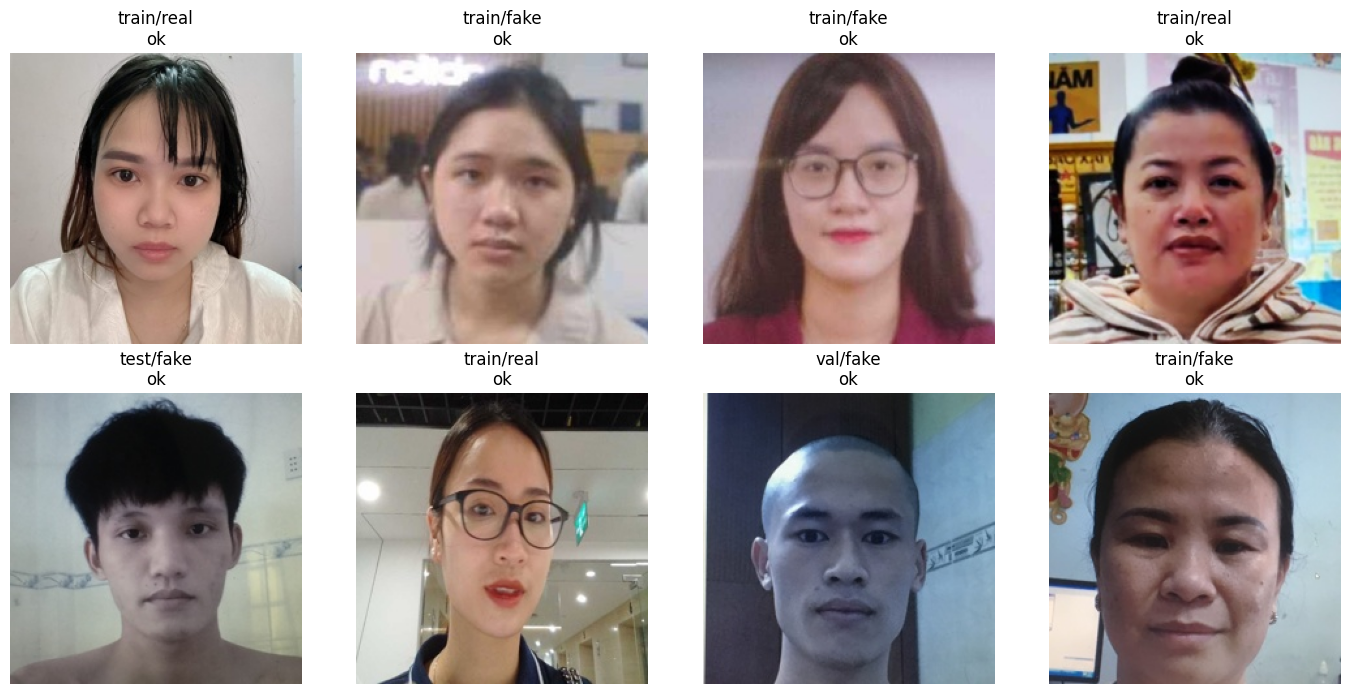

In [71]:
df_crop_ok = df_crop[df_crop["ok"] == True].copy()

sample_crop = df_crop_ok.sample(min(8, len(df_crop_ok)), random_state=42)

plt.figure(figsize=(14, 7))

for i, row in enumerate(sample_crop.itertuples(), 1):
    img = Image.open(row.dst_path).convert("RGB")
    
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(f"{row.split}/{row.label}\n{row.reason}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 69

In [72]:
from pathlib import Path
import pandas as pd
import os

BASE_DIR = Path(r"C:\Users\Hoannd\Downloads\data_face")

PROCESSED_DIR = BASE_DIR / "processed_vfa"
FACE_CROP_DIR = BASE_DIR / "processed_vfa_face_crop"
OUT_DIR = BASE_DIR / "vfa_work"
MODEL_DIR = BASE_DIR / "models"

paths = {
    "processed_vfa": PROCESSED_DIR,
    "processed_vfa_face_crop": FACE_CROP_DIR,
    "vfa_work": OUT_DIR,
    "models": MODEL_DIR,
    "split_metadata": OUT_DIR / "vfa_split_metadata.csv",
    "crop_metadata": OUT_DIR / "vfa_face_crop_metadata.csv",
    "best_model": MODEL_DIR / "vfa_mobilenetv3_small_best.pth",
    "deploy_config": MODEL_DIR / "vfa_deploy_config.json",
}

for name, path in paths.items():
    print(f"{name:25s}", path.exists(), path)

processed_vfa             True C:\Users\Hoannd\Downloads\data_face\processed_vfa
processed_vfa_face_crop   True C:\Users\Hoannd\Downloads\data_face\processed_vfa_face_crop
vfa_work                  True C:\Users\Hoannd\Downloads\data_face\vfa_work
models                    True C:\Users\Hoannd\Downloads\data_face\models
split_metadata            True C:\Users\Hoannd\Downloads\data_face\vfa_work\vfa_split_metadata.csv
crop_metadata             True C:\Users\Hoannd\Downloads\data_face\vfa_work\vfa_face_crop_metadata.csv
best_model                True C:\Users\Hoannd\Downloads\data_face\models\vfa_mobilenetv3_small_best.pth
deploy_config             True C:\Users\Hoannd\Downloads\data_face\models\vfa_deploy_config.json


# 70

In [73]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(root_dir):
    rows = []
    for split in ["train", "val", "test"]:
        for label in ["real", "fake"]:
            folder = root_dir / split / label
            count = 0
            if folder.exists():
                count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
            
            rows.append({
                "root": root_dir.name,
                "split": split,
                "label": label,
                "count": count
            })
    return pd.DataFrame(rows)

df_count_original = count_images(PROCESSED_DIR)
df_count_crop = count_images(FACE_CROP_DIR)

display(pd.concat([df_count_original, df_count_crop], ignore_index=True))

,root,split,label,count
0,processed_vfa,train,real,5745
1,processed_vfa,train,fake,2124
2,processed_vfa,val,real,1014
3,processed_vfa,val,fake,375
4,processed_vfa,test,real,782
5,processed_vfa,test,fake,1336
6,processed_vfa_face_crop,train,real,5745
7,processed_vfa_face_crop,train,fake,2124
8,processed_vfa_face_crop,val,real,1014
9,processed_vfa_face_crop,val,fake,375


# 71

In [74]:
import json
from datetime import datetime

checkpoint_state = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "base_dir": str(BASE_DIR),
    "processed_dir": str(PROCESSED_DIR),
    "face_crop_dir": str(FACE_CROP_DIR),
    "out_dir": str(OUT_DIR),
    "model_dir": str(MODEL_DIR),
    "split_metadata": str(OUT_DIR / "vfa_split_metadata.csv"),
    "crop_metadata": str(OUT_DIR / "vfa_face_crop_metadata.csv"),
    "best_model": str(MODEL_DIR / "vfa_mobilenetv3_small_best.pth"),
    "deploy_config": str(MODEL_DIR / "vfa_deploy_config.json"),
    "note": "Continue from this checkpoint. Do not rerun raw scan/copy/crop unless needed."
}

checkpoint_path = OUT_DIR / "project_checkpoint_state.json"

with open(checkpoint_path, "w", encoding="utf-8") as f:
    json.dump(checkpoint_state, f, ensure_ascii=False, indent=2)

print("Saved checkpoint:", checkpoint_path)
checkpoint_state

Saved checkpoint: C:\Users\Hoannd\Downloads\data_face\vfa_work\project_checkpoint_state.json


{'created_at': '2026-05-12 18:11:27',
 'base_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face',
 'processed_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\processed_vfa',
 'face_crop_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\processed_vfa_face_crop',
 'out_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\vfa_work',
 'model_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models',
 'split_metadata': 'C:\\Users\\Hoannd\\Downloads\\data_face\\vfa_work\\vfa_split_metadata.csv',
 'crop_metadata': 'C:\\Users\\Hoannd\\Downloads\\data_face\\vfa_work\\vfa_face_crop_metadata.csv',
 'best_model': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models\\vfa_mobilenetv3_small_best.pth',
 'deploy_config': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models\\vfa_deploy_config.json',
 'note': 'Continue from this checkpoint. Do not rerun raw scan/copy/crop unless needed.'}